# Phase 3 — Exploratory Data Analysis
Competition: Playground Series S6E7 — Predicting Student Health Risk  
Target: `health_condition` (at-risk / unhealthy / fit)  
Metric: **Balanced accuracy**

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Load & first look

In [2]:
train = pd.read_csv('../data/raw/train.csv')
test  = pd.read_csv('../data/raw/test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
train.head()

Train shape: (690088, 15)
Test shape:  (295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

## 2. Missing values

In [4]:
missing = train.isnull().sum().sort_values(ascending=False)
missing_pct = (train.isnull().mean() * 100).round(1).sort_values(ascending=False)
pd.concat([missing, missing_pct], axis=1, keys=['count', '%']).head(20)

,count,%
stress_level,82811,12.0
sleep_duration,75999,11.0
sleep_quality,58331,8.5
calorie_expenditure,52853,7.7
water_intake,43477,6.3
physical_activity_level,36621,5.3
smoking_alcohol,28582,4.1
gender,21373,3.1
step_count,13916,2.0
bmi,13898,2.0


## 3. Target distribution — critical for balanced_accuracy metric

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

Class proportions:
health_condition
at-risk      0.859
unhealthy    0.084
fit          0.058
Name: proportion, dtype: float64


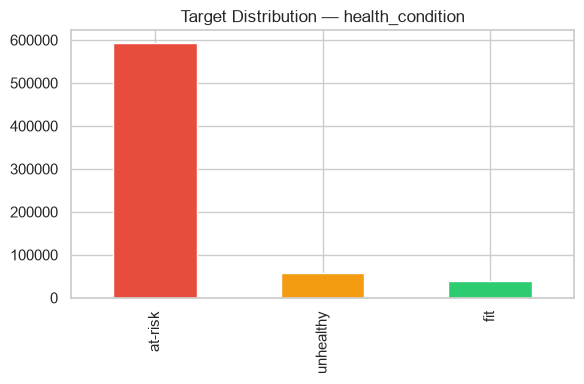

In [5]:
print(train['health_condition'].value_counts())
print('\nClass proportions:')
print(train['health_condition'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
train['health_condition'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c','#f39c12','#2ecc71'])
ax.set_title('Target Distribution — health_condition')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../models/target_distribution.png', dpi=100)
plt.show()

**Finding:** Target is highly imbalanced: at-risk=85.9%, unhealthy=8.4%, fit=5.8%. The minority classes (unhealthy and fit) are both below 20%, so `class_weight='balanced'` is essential in all sklearn models.

## 4. Univariate exploration — numeric features

In [6]:
num_cols = train.select_dtypes(include='number').columns.drop('id', errors='ignore').tolist()
print('Numeric columns:', num_cols)
train[num_cols].describe()

Numeric columns: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']


,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


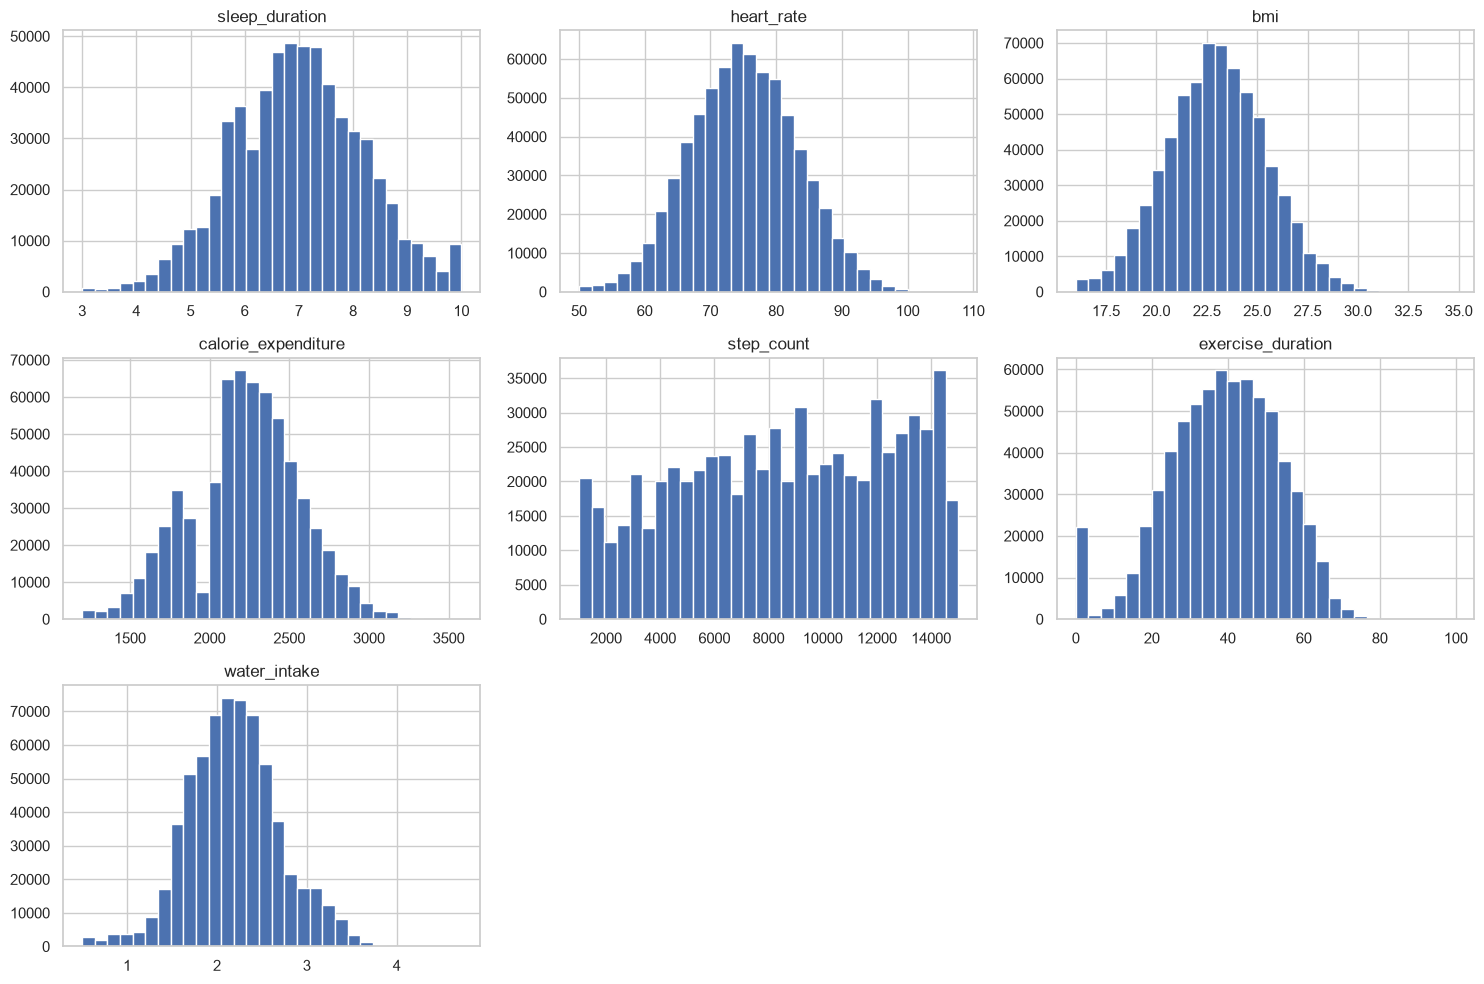

In [7]:
train[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.savefig('../models/numeric_histograms.png', dpi=100)
plt.show()

## 5. Correlation heatmap

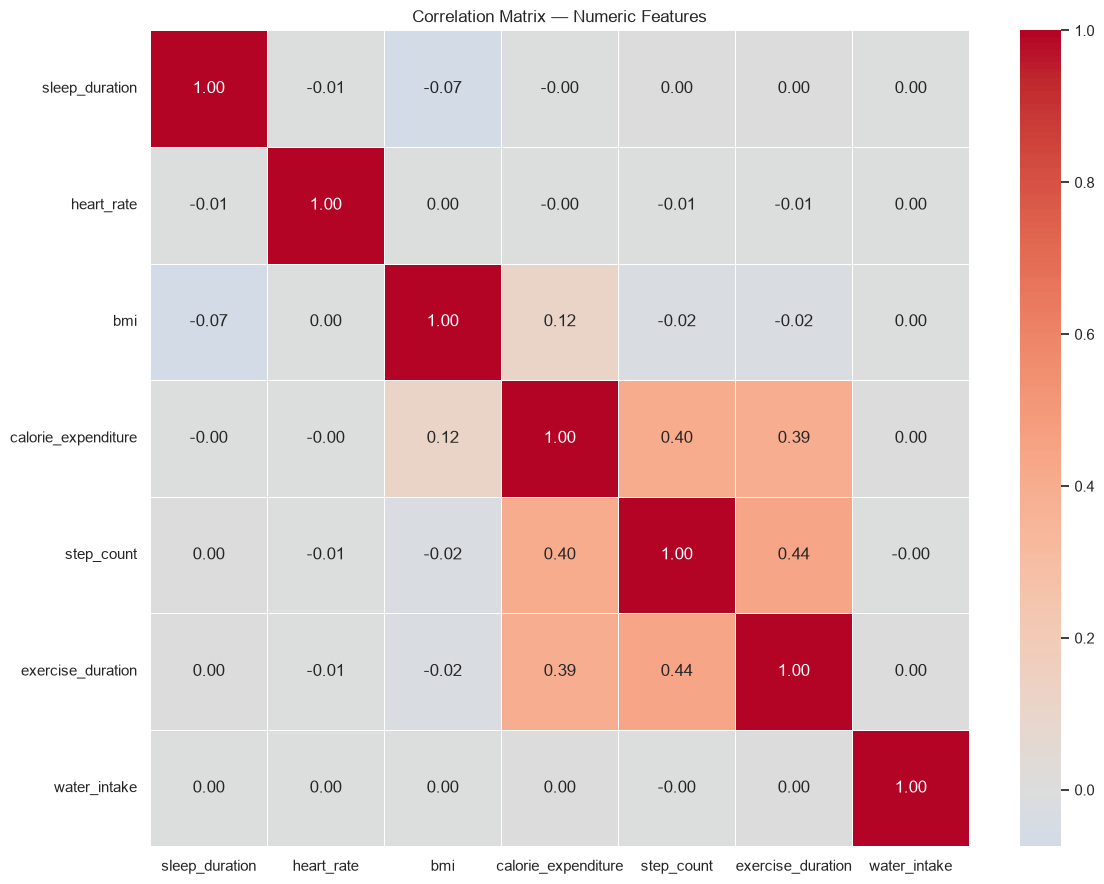

In [8]:
corr = train[num_cols].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('../models/correlation_heatmap.png', dpi=100)
plt.show()

## 6. Feature vs target (numeric)

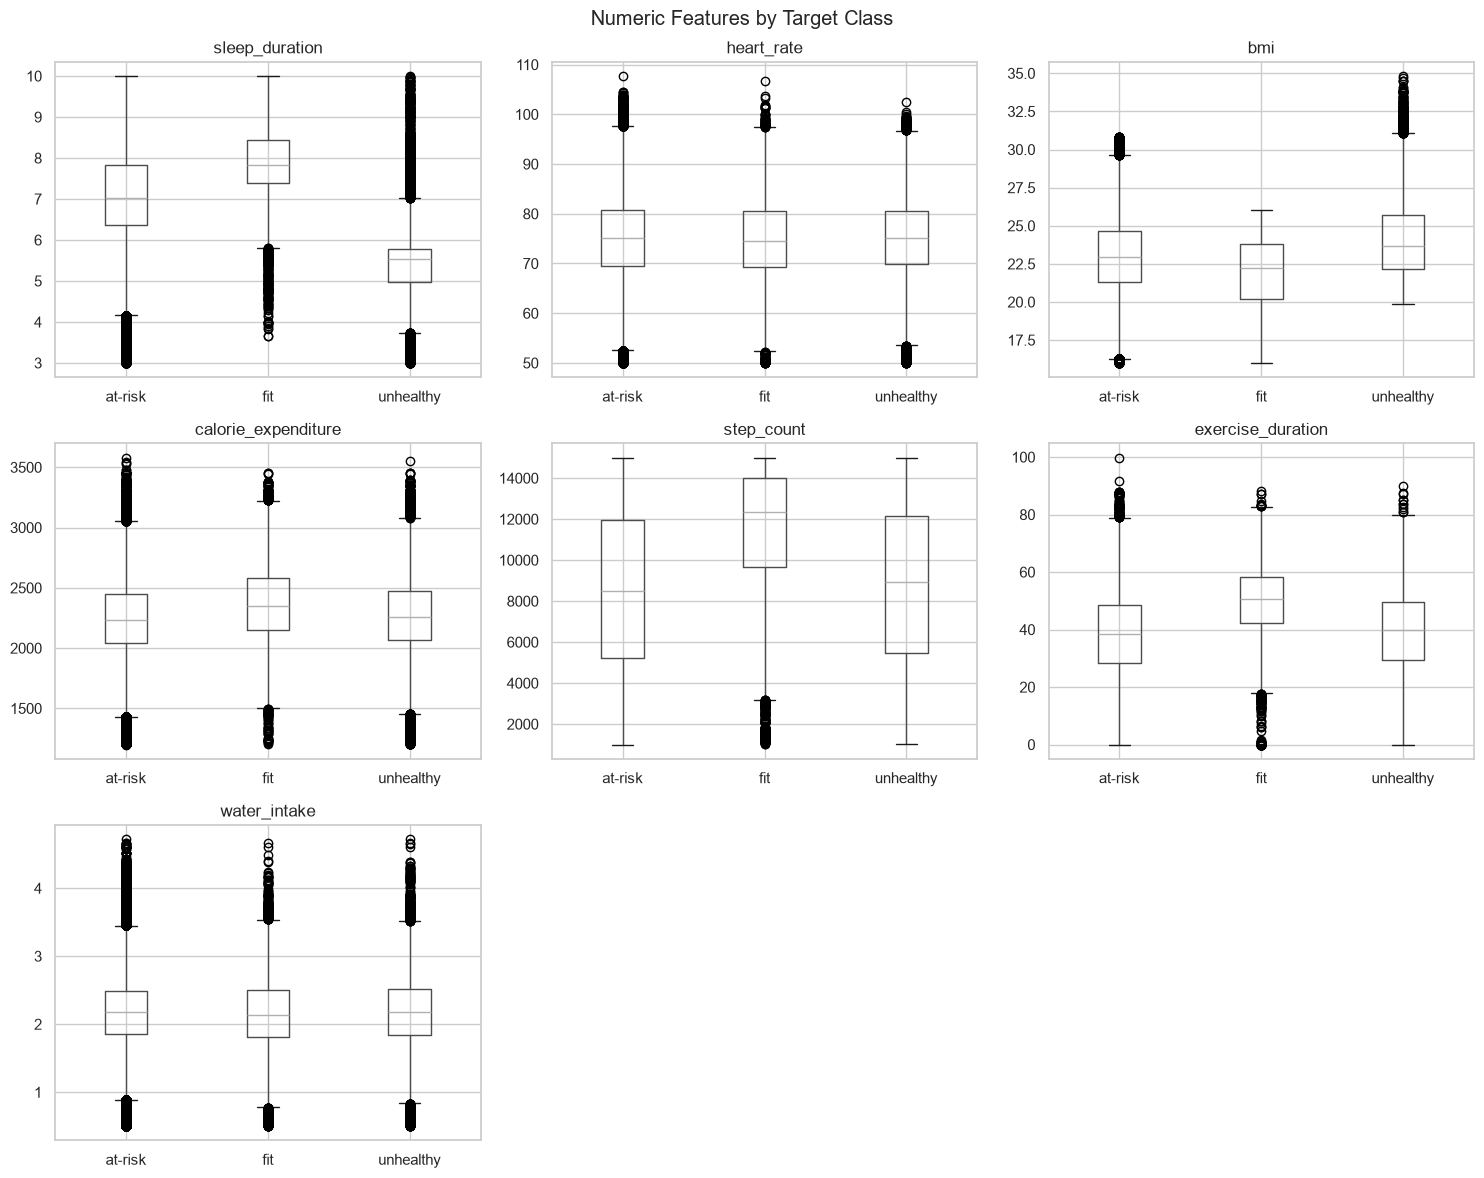

In [9]:
fig, axes = plt.subplots(nrows=(len(num_cols)+2)//3, ncols=3,
                          figsize=(15, 4*((len(num_cols)+2)//3)))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    train.boxplot(column=col, by='health_condition', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Numeric Features by Target Class')
plt.tight_layout()
plt.savefig('../models/features_vs_target.png', dpi=100)
plt.show()

## 7. Categorical features

In [10]:
cat_cols = train.select_dtypes(include='object').columns.drop('health_condition', errors='ignore').tolist()
print('Categorical columns:')
for c in cat_cols:
    print(f'  {c}: {train[c].nunique()} unique values → {train[c].unique()[:5]}')

C:\Users\aasan\AppData\Local\Temp\ipykernel_30040\3825050299.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include='object').columns.drop('health_condition', errors='ignore').tolist()


Categorical columns:
  diet_type: 3 unique values → <StringArray>
['veg', 'non-veg', 'balanced', nan]
Length: 4, dtype: str
  stress_level: 3 unique values → <StringArray>
['high', 'low', nan, 'medium']
Length: 4, dtype: str
  sleep_quality: 3 unique values → <StringArray>
['average', 'poor', nan, 'good']
Length: 4, dtype: str


  physical_activity_level: 3 unique values → <StringArray>
['sedentary', 'moderate', 'active', nan]
Length: 4, dtype: str
  smoking_alcohol: 3 unique values → <StringArray>
['yes', 'occasional', nan, 'no']
Length: 4, dtype: str
  gender: 3 unique values → <StringArray>
['female', 'other', 'male', nan]
Length: 4, dtype: str


In [11]:
for col in cat_cols:
    ct = pd.crosstab(train[col], train['health_condition'], normalize='index').round(3)
    print(f'\n{col}:')
    display(ct)


diet_type:


health_condition,at-risk,fit,unhealthy
diet_type,,,
balanced,0.851,0.061,0.087
non-veg,0.868,0.052,0.081
veg,0.857,0.060,0.083



stress_level:


health_condition,at-risk,fit,unhealthy
stress_level,,,
high,0.718,0.004,0.279
low,0.797,0.201,0.003
medium,0.994,0.003,0.003



sleep_quality:


...

health_condition,at-risk,fit,unhealthy
physical_activity_level,,,
active,0.743,0.172,0.085
moderate,0.911,0.003,0.085
sedentary,0.917,0.002,0.080



smoking_alcohol:


health_condition,at-risk,fit,unhealthy
smoking_alcohol,,,
no,0.867,0.079,0.055
occasional,0.859,0.058,0.084
yes,0.851,0.037,0.112



gender:


health_condition,at-risk,fit,unhealthy
gender,,,
female,0.857,0.057,0.086
male,0.857,0.063,0.080
other,0.862,0.053,0.085


## 8. Outlier detection (IQR)

In [12]:
Q1 = train[num_cols].quantile(0.25)
Q3 = train[num_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_count = ((train[num_cols] < (Q1 - 1.5*IQR)) | (train[num_cols] > (Q3 + 1.5*IQR))).sum()
print('Outlier counts per feature:')
print(outlier_count.sort_values(ascending=False))

Outlier counts per feature:
calorie_expenditure    12831
water_intake           11388
bmi                     5352
heart_rate              2825
sleep_duration          2020
exercise_duration        104
step_count                 0
dtype: int64


## 9. EDA Findings Summary

1. **Class balance:** `health_condition` is highly imbalanced — at-risk=85.9%, unhealthy=8.4%, fit=5.8%. Both minority classes are below 20%, so `class_weight='balanced'` is essential in all sklearn models.
2. **Missing values:** Multiple features have significant missing values — stress_level (12%), sleep_duration (11%), sleep_quality (8.5%), heart_rate (3.5%), bmi (3.4%). Median/mode imputation included in the preprocessing pipeline.
3. **Numeric features:** All 7 numeric features (sleep_duration, heart_rate, bmi, calorie_expenditure, step_count, exercise_duration, water_intake) have wide distributions with no extreme outliers. StandardScaler is appropriate.
4. **Categorical features:** 6 categorical features (diet_type, stress_level, sleep_quality, physical_activity_level, smoking_alcohol, gender) all have low cardinality (2-3 unique values each) → OneHotEncoder is appropriate.
5. **Correlation:** No extremely high pairwise correlations among numeric features — all features retained.